# Understanding Faults
* Faults exist in TVT
* Near wells should exhibit similar faults. (NOT TRUE IN THE DATA)
* Need fault length and fault location
* Could have used near wells for feature engineering
* Same/Similar Z vs TVT for near by wells

**FOUND OUT THAT FAULTS ARE VERY GENERICALLY ADDED BY THE GEOLOGIST, AND NOT KEPT TRACK OF**

In [1]:
import os
import glob
import numpy as np
np.random.seed(42)
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import re
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Automatically detect if running on Kaggle or Locally
IS_KAGGLE = os.path.exists('/kaggle/input')
BASE_DIR = '/kaggle/input/competitions/rogii-wellbore-geology-prediction' if IS_KAGGLE else '../data'

print(f"Running on {'Kaggle' if IS_KAGGLE else 'Local Environment'}")
print(f"Data Directory: {BASE_DIR}")
train_data = os.path.join(BASE_DIR, "train")
file_paths = sorted(os.listdir(train_data))

# Regex pattern: 
pattern = re.compile(r'([^/\\]+)__horizontal_well\.csv')

well_names = []
for path in file_paths:
    match = pattern.search(path)
    if match:
        well_names.append(match.group(1))

print("Extracted Well Names:")
print(len(well_names), "Well Names")

Running on Local Environment
Data Directory: ../data
Extracted Well Names:
773 Well Names


In [3]:
well = np.random.choice(well_names)
# well = 'ccedb12b'
well = 'dd7d638e'
well = '0e5e560d'

hw = pd.read_csv(train_data + f"/{well}__horizontal_well.csv")
tw = pd.read_csv(train_data + f"/{well}__typewell.csv")
pic = train_data + f"/{well}.png"

mask = hw['TVT_input'].isna()
evalz = hw[mask].copy()

well, hw.shape, tw.shape, evalz.shape

('0e5e560d', (4896, 13), (1833, 3), (3253, 13))

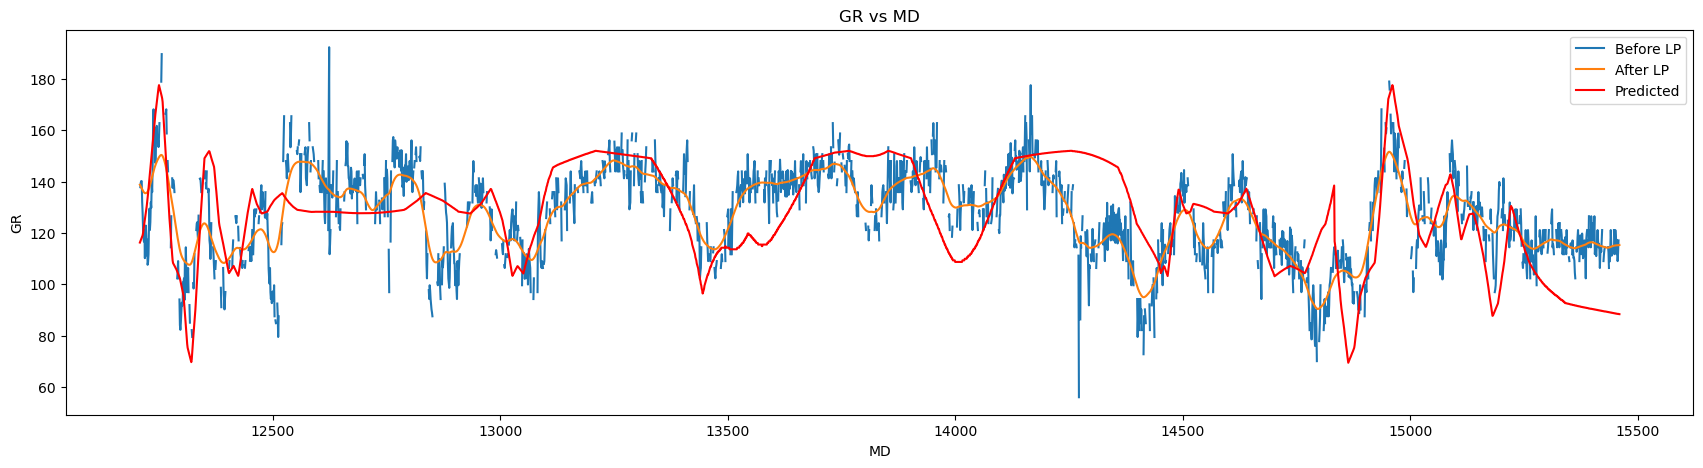

In [4]:
from scipy.signal import butter, filtfilt
from scipy.stats import pearsonr

HW_LOW_PASS_CUTOFF = 0.009
def remove_rotation_noise(gr_series, cutoff=HW_LOW_PASS_CUTOFF):
    """Low pass filter."""
    gr_filled = gr_series.interpolate(method='linear').bfill().ffill()
    nyquist = 0.5 
    normal_cutoff = cutoff / nyquist
    b, a = butter(1, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, gr_filled)

plt.figure(figsize=(21, 5))
plt.plot(evalz['MD'], evalz['GR'], label='Before LP')
    
evalz['GR'] = remove_rotation_noise(evalz['GR'])
pred_gr = np.interp(evalz['TVT'], tw['TVT'], tw['GR'])

plt.plot(evalz['MD'], evalz['GR'], label='After LP')
plt.plot(evalz['MD'], pred_gr, label='Predicted', color='red')
plt.title('GR vs MD')
plt.xlabel('MD')
plt.ylabel('GR')
plt.legend()

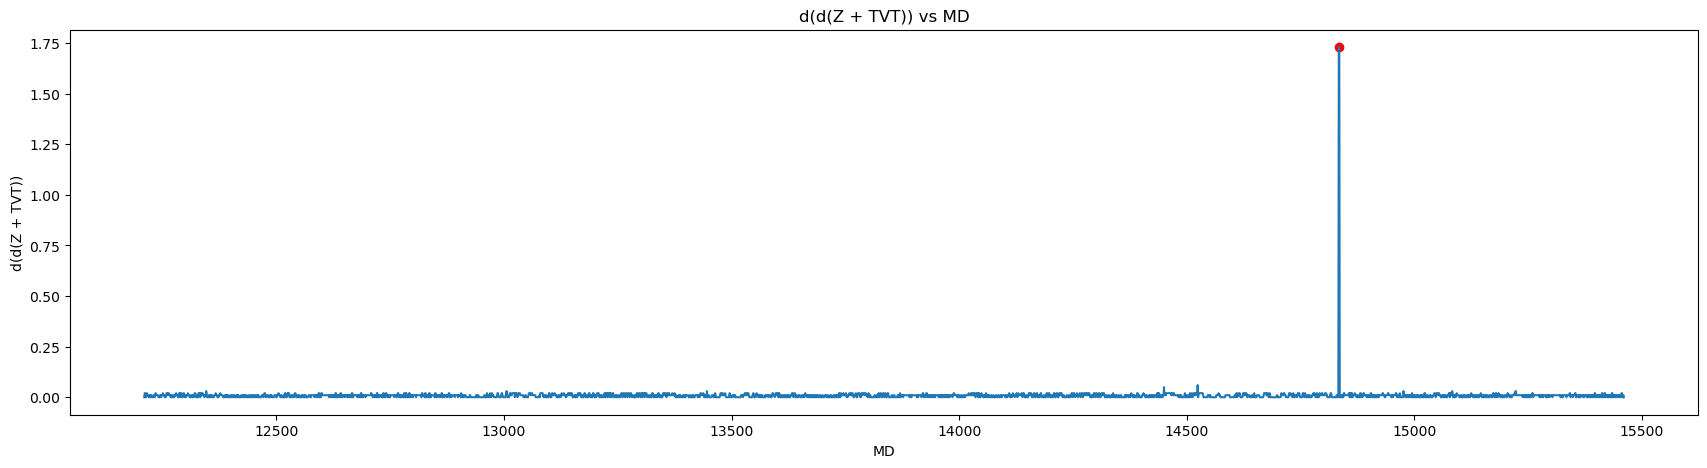

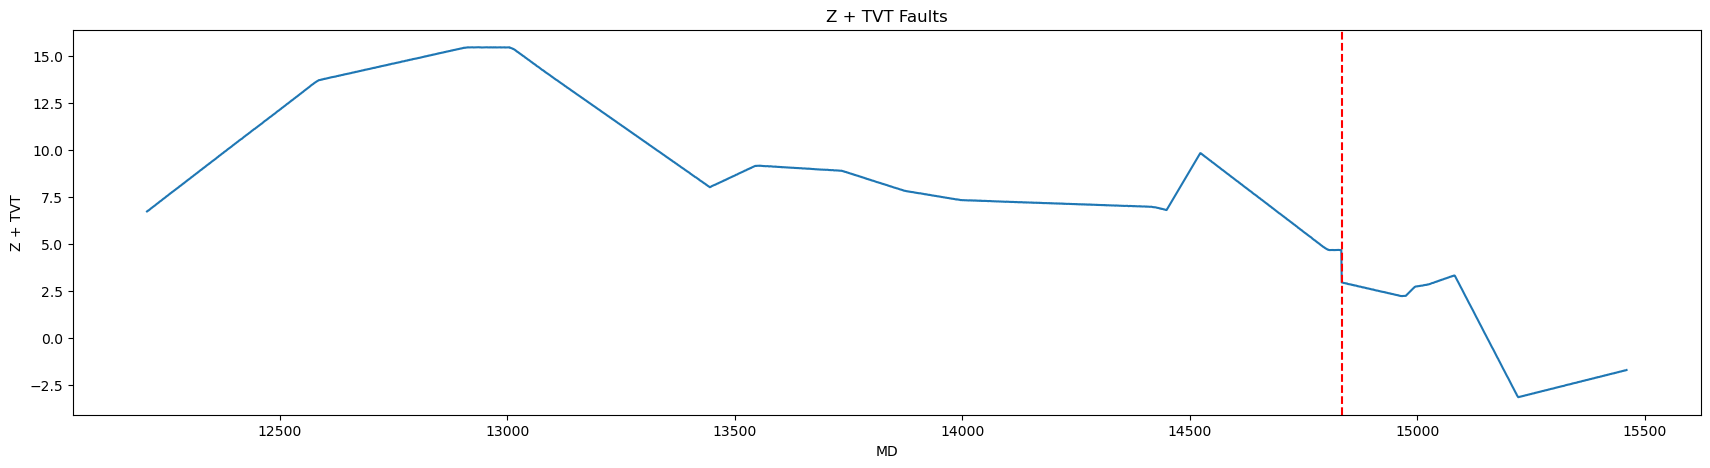

In [5]:
tvt0 = hw[~mask]['TVT'].iloc[-1]

m, c = np.polyfit(evalz['MD'], evalz['Z'], deg=1)
evalz['norm_Z'] = (m * evalz['MD'] + c) - evalz['Z']
evalz['norm_TVT'] = evalz['TVT'] - tvt0
evalz['Z+TVT'] = evalz['norm_TVT'] - evalz['norm_Z'] 

d = lambda df: df.diff()#.rolling(window=3).mean()
evalz['dZ+dTVT'] = d(evalz['Z+TVT'])

from scipy.signal import find_peaks
plt.figure(figsize=(21, 5))
dd = np.abs(d(evalz['dZ+dTVT']))
peaks, properties = find_peaks(dd, distance=20, height=0.3)
plt.plot(evalz['MD'], dd)
plt.scatter(evalz['MD'].iloc[peaks], dd.iloc[peaks], color='red')
plt.title('d(d(Z + TVT)) vs MD')
plt.ylabel('d(d(Z + TVT))')
plt.xlabel('MD')

plt.figure(figsize=(21, 5))
plt.plot(evalz['MD'], evalz['Z+TVT'])
plt.title('Z + TVT Faults')
plt.xlabel('MD')
plt.ylabel('Z + TVT')
for pos in evalz['MD'].iloc[peaks]:
    plt.axvline(x=pos, color='r', linestyle='--')

In [6]:
x = hw.iloc[0]['X']
x_close = float('inf')
y = hw.iloc[0]['Y']
y_close = float('inf')
for w in well_names:
    h = pd.read_csv(train_data + f"/{w}__horizontal_well.csv")
    x_h = h.iloc[0]['X']
    y_h = h.iloc[0]['Y']
    if (x - x_h)**2 + (y - y_h)**2 < (x - x_close) **2 + (y - y_close)**2 and w != well:
        x_close = x_h
        y_close = y_h
        w_close = w
x, x_close, y, y_close, w_close

(np.float64(3010110.75),
 np.float64(3008373.68),
 np.float64(1128343.29),
 np.float64(1128825.33),
 '4121c517')

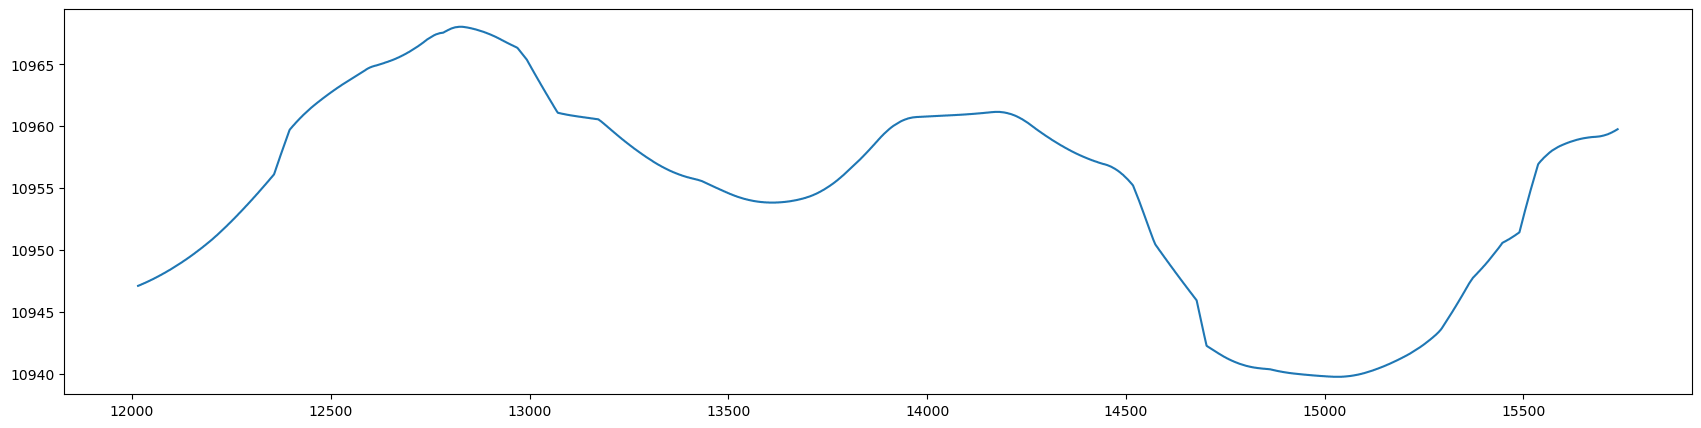

In [7]:
plt.figure(figsize=(21, 5))
h = pd.read_csv(train_data + f"/{w_close}__horizontal_well.csv")
t = pd.read_csv(train_data + f"/{w_close}__typewell.csv")
e = h[h['TVT_input'].isna()]
plt.plot(e['MD'], e['TVT'])
# plt.plot(evalz['MD'], evalz['TVT'])

In [8]:
# Closest Well Faults
hw = h
tw = t
evalz = e
mask = h['TVT_input'].isna()

## Fault Size

In [9]:
fault_wells = []

for w in well_names:
    h = pd.read_csv(train_data + f"/{w}__horizontal_well.csv")
    mask = h["TVT_input"].isna()
    e = h[mask]
    
    tvt0 = h[~mask]['TVT'].iloc[-1]
    m, c = np.polyfit(e['MD'], e['Z'], deg=1)
    e['norm_Z'] = (m * e['MD'] + c) - e['Z']
    e['norm_TVT'] = e['TVT'] - tvt0
    e['Z+TVT'] = e['norm_TVT'] - e['norm_Z'] 
    
    d = e["Z+TVT"].diff()
    faults = d.abs() > 1
    
    # Check if any fault exists in the well
    if faults.any():
        fault_wells.append({
            "well": w,
            "X": e["X"][faults].values,
            "Y": e["Y"][faults].values,
            "Z": e["Z"][faults].values,
            "TVT": e["TVT"][faults].values,
            "jumps": d[faults].values
        })

In [10]:
f = pd.DataFrame(fault_wells)
f.head()

,well,X,Y,Z,TVT,jumps
0,00bbac68,[3007932.63],[1087426.26],[-10088.3],[12225.31],[-9.252372677407038]
1,059c8f24,[2917811.16],[1061533.99],[-8589.85],[10316.4],[8.201647315172522]
2,06df5958,[2905004.99],[1025542.03],[-9370.65],[11338.94],[-1.702373168851409]
3,0849b4e2,"[3021710.18, 3021822.02]","[1114169.31, 1112857.95]","[-9930.75, -9952.1]","[11931.53, 11912.27]","[1.3013110045012581, -2.628688995499033]"
4,084d66f9,"[2930784.64, 2930925.94, 2931277.95, 2931619.6...","[1055353.87, 1055210.05, 1054825.57, 1054406.4...","[-8952.51, -8964.83, -8984.18, -8987.72, -9040...","[11006.2, 11011.91, 11019.96, 11013.23, 11000.84]","[-1.6297806487291382, 2.6502193512715166, 8.21..."


In [11]:
fault_jumps = np.concat([w["jumps"] for w in fault_wells])

In [12]:
fault_jumps.mean(), fault_jumps.std(), fault_jumps.max(), fault_jumps.min(), np.abs(fault_jumps).min(), np.abs(fault_jumps).mean()

(np.float64(-0.08286193574885677),
 np.float64(3.110011238489095),
 np.float64(15.61421070691722),
 np.float64(-9.252372677407038),
 np.float64(1.0010159867761104),
 np.float64(2.5163136325854083))

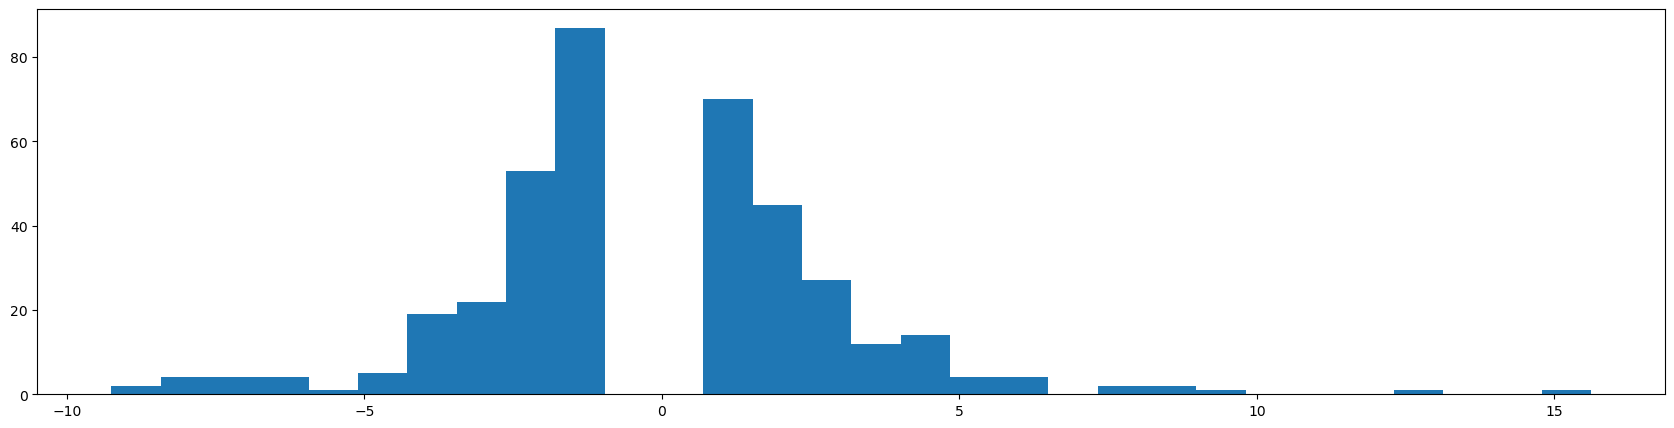

In [13]:
plt.figure(figsize=(21, 5))
plt.hist(fault_jumps, bins=30)
plt.show()

In [187]:
# f.to_csv('../data/well_faults.csv')